In [7]:
from pathlib import Path
import sys
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

In [29]:
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "01_data" / "processed" / "model_df.csv"

# 03_final/models 폴더 생성
SAVE_DIR = BASE_DIR / "03_final" / "models"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(BASE_DIR))

from src.preprocessing import fit_preprocessing, transform_preprocessor

In [30]:
# 1. 데이터 로드

df = pd.read_csv(DATA_PATH)

X = df.drop("churned", axis=1)
y = df["churned"]

In [31]:
# 2. train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# 3. 최종 학습용 전처리

X_train_prep_final, encoders_final, scaler_final = fit_preprocessing(X_train)
X_test_prep_final = transform_preprocessor(X_test, encoders_final, scaler_final)


In [33]:
# 4. 최종 선택 모델의 best params

best_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

In [34]:
# 5. 최종 모델 정의 및 학습

final_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
    **best_params
)

final_model.fit(X_train_prep_final, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [35]:
# 6. 예측

y_test_pred = final_model.predict(X_test_prep_final)
y_test_proba = final_model.predict_proba(X_test_prep_final)[:, 1]

In [36]:
# 7. 평가

print("\n" + "=" * 60)
print("Final XGBoost Model Evaluation")
print("=" * 60)

print("\n[Best Params]")
print(best_params)

print("\n[Classification Report]")
print(classification_report(y_test, y_test_pred))

print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_test_proba):.4f}")



Final XGBoost Model Evaluation

[Best Params]
{'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8}

[Classification Report]
              precision    recall  f1-score   support

           0       0.84      0.85      0.85     12165
           1       0.86      0.85      0.85     12835

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000

Accuracy : 0.8484
F1 Score : 0.8483
ROC AUC  : 0.9420


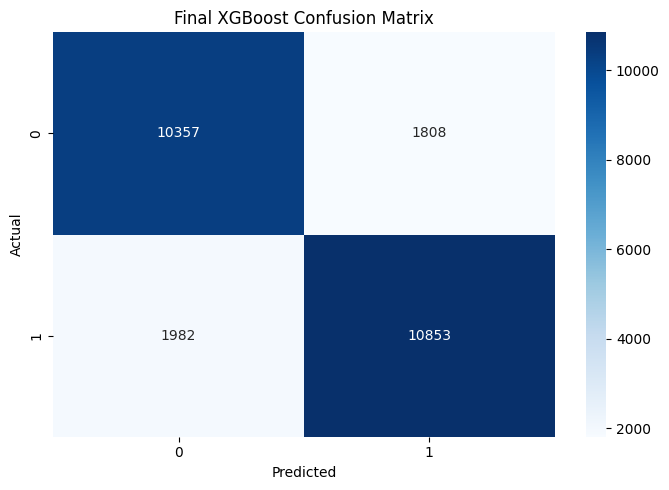

In [37]:
# 8. 혼동행렬 시각화

plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Final XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [38]:
# 9. 모델 저장
# -----------------------------
joblib.dump(final_model, SAVE_DIR / "final_xgb_model.pkl")
joblib.dump(encoders_final, SAVE_DIR / "xgb_encoders.pkl")
joblib.dump(scaler_final, SAVE_DIR / "xgb_scaler.pkl")

print("\n모델 저장 완료")
print(SAVE_DIR / "final_xgb_model.pkl")


모델 저장 완료
C:\project\JANI\03_models\models\final_xgb_model.pkl
